# Module 02: Probability Basics for Machine Learning

## Week 01_Module 02_Part 01

---

এই module-এ যা যা শিখবো:

**১. Events, Sample Space & Basic Probability Rules**
সম্ভাবনার মূল ধারণা — কোনো ঘটনা ঘটার সম্ভাবনা কীভাবে হিসাব করে।

**২. Conditional Probability & Independence**
একটি ঘটনা ঘটলে অন্যটির সম্ভাবনা কতটা বদলায় — এবং দুটো ঘটনা কখন একে অপরের উপর নির্ভরশীল নয়।

**৩. Bayes' Theorem**
- **Intuitive level** — বাস্তব উদাহরণ দিয়ে বোঝা
- **Formula level** — গাণিতিকভাবে হিসাব করা
- **Base-rate effects** — পূর্বের তথ্য কীভাবে সম্ভাবনা বদলে দেয়

**৪. Sensitivity, Specificity, False Positive/Negative, PPV & NPV**
Medical testing ও ML-এ কতটা সঠিকভাবে model সিদ্ধান্ত নিচ্ছে তা পরিমাপ করার পদ্ধতি।

**৫. Class Imbalance & Error Interpretation**
Dataset-এ একটি class অনেক বেশি থাকলে model-এর error কীভাবে ভুলভাবে ব্যাখ্যা হতে পারে।

---

# 🎲 Probability কী এবং ML-এ কেন দরকার?

---

## 📌 মূল ধারণা

**Probability** হলো **অনিশ্চয়তার গণিত** — কোনো ঘটনা ঘটার সম্ভাবনা কতটুকু তা পরিমাপ করে।

ML-এ probability জরুরি কারণ model কখনো **absolute সিদ্ধান্ত** নেয় না — বরং data-র উপর ভিত্তি করে outcome-এর **likelihood estimate** করে।

---

## 🧮 উদাহরণ

| Situation | Probability | অর্থ |
|---|---|---|
| Email spam হওয়ার সম্ভাবনা | 0.9 | Model **90% confident** এটি spam |
| Loan default হওয়ার সম্ভাবনা | 0.2 | **20% risk** of default |
| Patient-এর diabetes থাকার সম্ভাবনা | 0.6 | আরও পরীক্ষার দরকার হতে পারে |

---

## 🤖 ML-এ Probability-র ভূমিকা

Probability, ML system-কে সক্ষম করে —
- 🔵 **Noise** সামলাতে
- 🟡 **Uncertainty** handle করতে
- 🟢 **Incomplete information** থাকলেও যুক্তিসঙ্গত prediction করতে

---

# 🎲 1. Events, Sample Space & Basic Rules

---

## 📌 মূল সংজ্ঞা

**Event** → একটি নির্দিষ্ট outcome
- যেমন: dice-এ জোড় সংখ্যা পাওয়া

**Sample Space** → সব সম্ভাব্য outcome-এর সমষ্টি
- যেমন: `{1, 2, 3, 4, 5, 6}`

**Rule:**
$$P(\text{Event}) = \frac{\text{Favorable outcomes}}{\text{Total outcomes}}$$

---

## 🧮 উদাহরণ

$$P(\text{Even}) = \frac{3}{6} = 0.5$$

জোড় সংখ্যা → `{2, 4, 6}` = 3টি, মোট = 6টি

---

## 🤖 ML-এ Event-এর উদাহরণ

- "Customer buys product" → হবে কি হবে না?
- "Model predicts positive" → সঠিক কি ভুল?

---

# 🔗 2. Conditional Probability & Independence

---

## 📌 Conditional Probability কী?

**B ঘটে গেলে A ঘটার সম্ভাবনা** কতটুকু — এটাই Conditional Probability।

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

**উদাহরণ:**
$$P(\text{Ice cream} \mid \text{Hot day})$$
→ গরমের দিনে ice cream কেনার সম্ভাবনা বেড়ে যায় — একটি factor আরেকটির likelihood বদলে দেয়।

---

## 🤖 ML-এ ব্যবহার

$$P(\text{Class} \mid \text{Features})$$
→ Input data দেওয়া থাকলে কোন label হওয়ার সম্ভাবনা কত — এটাই ML model শেখে।

---

## 🔀 Independence কী?

A ও B **independent** যদি —
$$P(A \mid B) = P(A)$$
অর্থাৎ B ঘটলেও A-র সম্ভাবনা **একটুও বদলায় না**।

---

## 🧠 Naïve Bayes Connection

**Naïve Bayes classifier** সরলতার জন্য সব features-কে **independent** ধরে নেয় — যদিও বাস্তব data-তে এটি সত্যি নয়।

---

# 🧠 3. Bayes' Theorem & Base-Rate Effects

---

## 📌 মূল ধারণা

নতুন **evidence** পেলে আমাদের পুরনো **belief আপডেট** করার গাণিতিক পদ্ধতি।

$$P(A \mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

---

## 💡 Intuition — তিনটি ধাপ

| ধাপ | নাম | অর্থ |
|---|---|---|
| **১** | **Prior** | আগে থেকে যা বিশ্বাস করি |
| **২** | **Likelihood** | নতুন data দেখলাম |
| **৩** | **Posterior** | বিশ্বাস আপডেট করলাম |

---

## ⚠️ Base-Rate Effect — গুরুত্বপূর্ণ উদাহরণ

একটি disease test **99% accurate**, কিন্তু রোগটি মাত্র **10,000 জনে 1 জনের** হয়।

> এই অবস্থায় **positive result** আসলেও বেশিরভাগই **false alarm**!

কারণ → রোগটি এত **বিরল** যে accurate test-ও বিভ্রান্তিকর হয়ে পড়ে — এটাই **Base-Rate Effect**।

---

## 🤖 ML-এ শিক্ষা

প্রতিটি class কতটা **common** তার উপর ভিত্তি করে model-এর **expectation adjust** করতে হয় — নইলে rare class-এ বড় ভুল হয়।

---

# 📊 4. Sensitivity, Specificity & Error Rates

---

## 📌 মূল ধারণা

এই সব concept আসে **Confusion Matrix** থেকে — যা model evaluate করার মূল tool।

---

## 🔢 মূল Metrics

| Metric | অর্থ |
|---|---|
| **Sensitivity** (True Positive Rate) | আসল positive-গুলো সঠিকভাবে detect করা |
| **Specificity** (True Negative Rate) | আসল negative-গুলো সঠিকভাবে detect করা |
| **False Positive** | আসলে negative, কিন্তু model বলছে positive |
| **False Negative** | আসলে positive, কিন্তু model বলছে negative |
| **PPV** (Positive Predictive Value) | Positive prediction কতবার সত্যিই সঠিক |
| **NPV** (Negative Predictive Value) | Negative prediction কতবার সত্যিই সঠিক |

---

## ⚖️ কোনটা বেশি গুরুত্বপূর্ণ?

| লক্ষ্য | কোনটা গুরুত্বপূর্ণ |
|---|---|
| সব positive case ধরতে চাই | **Sensitivity** বাড়াও |
| False alarm এড়াতে চাই | **Specificity** বাড়াও |

> 💡 **উদাহরণ:** Cancer detection-এ **Sensitivity** বেশি জরুরি — একটি রোগীও miss করা যাবে না। Spam filter-এ **Specificity** জরুরি — important email spam folder-এ যাওয়া উচিত নয়।

---

# ⚖️ 5. Class Imbalance & Its Impact

---

## 📌 Class Imbalance কী?

বাস্তব জীবনের বেশিরভাগ dataset-এ **একটি class অনেক বেশি** — এটাই **Class Imbalance**।

---

## 🚨 উদাহরণ — Fraud Detection

10,000টি transaction-এর মধ্যে মাত্র **50টি fraudulent (0.5%)**।

একটি model যদি সবসময় **"no fraud"** বলে —
- Accuracy = **99.5%** ✅
- কিন্তু model সম্পূর্ণ **useless** ❌

> ⚠️ তাই **Accuracy একা যথেষ্ট নয়।**

---

## 🔧 সমাধান — কী ব্যবহার করবো?

Minority class model কতটা ভালো handle করছে তা বুঝতে ব্যবহার করো:

- **PPV** (Positive Predictive Value)
- **NPV** (Negative Predictive Value)
- **Bayesian reasoning**

---

## 🔮 পরের Module-এ যা আসছে

এই ধারণাগুলো তোমাকে প্রস্তুত করবে:

| Metric | কী পরিমাপ করে |
|---|---|
| **Precision** | Positive prediction কতটা সঠিক |
| **Recall** | আসল positive কতটা ধরা পড়েছে |
| **F1-Score** | Precision ও Recall-এর balanced measure |

---

# 🎯 Module 02 — Goal & Checklist

---

## এই Module শেষে তুমি পারবে —

- ☑️ ML context-এ **probability** concepts ব্যাখ্যা করতে
- ☑️ **Bayes' Theorem** intuitively apply করতে
- ☑️ **Confusion matrix** metrics — **Sensitivity, Specificity, PPV, NPV** interpret করতে
- ☑️ **Class imbalance** কীভাবে model accuracy-কে distort করে তা চিনতে

> 🔑 **মনে রাখো:** Machine Learning মানে certainty নয় — এটা হলো **uncertainty-র মধ্যে smart decision নেওয়া।**

---

# 🎲 1. Probability কী?

---

## 📌 মূল ধারণা

**Probability** হলো **uncertainty-র পরিমাপ** — কোনো কিছু ঘটার সম্ভাবনা কতটুকু তা বলে।

$$P(\text{Event}) = \frac{\text{Number of favorable outcomes}}{\text{Total number of outcomes}}$$

---

## 🧮 উদাহরণ

- 🪙 Fair coin flip → **heads** পাওয়ার সম্ভাবনা = **0.5 (50%)**
- 📧 ML model বলছে email spam → probability = **0.9** মানে model **90% confident**

---

## 🔢 Probability-র সীমা

| মান | অর্থ |
|---|---|
| **0** | ঘটনাটি কখনোই ঘটবে না |
| **0.5** | ঘটবে বা ঘটবে না — সমান সম্ভাবনা |
| **1** | ঘটনাটি নিশ্চিতভাবে ঘটবে |

---

# 🌐 2. Sample Space

---

## 📌 Sample Space কী?

**Sample Space (S)** হলো একটি experiment-এর **সব সম্ভাব্য outcome-এর সমষ্টি**।

---

## 🧮 উদাহরণ

| Experiment | Sample Space |
|---|---|
| Coin toss | S = `{Heads, Tails}` |
| Dice roll | S = `{1, 2, 3, 4, 5, 6}` |

---

## 🤖 ML-এ Sample Space

ML-এ **Sample Space** = **সব সম্ভাব্য data points-এর universe**।

**উদাহরণ:** কোনো student pass করবে কি fail করবে — এটা predict করতে গেলে Sample Space-এ থাকবে study hours, attendance এবং outcomes (pass/fail)-এর **সব combinations**।

> 🔑 **Key Takeaway:** Sample Space সেই **জগৎ** define করে যেখানে তোমার **probability model** বাস করে — ঠিক যেভাবে dataset সেই জগৎ define করে যেখান থেকে তোমার **ML model** শেখে।

---

# 💡 3. Events

---

## 📌 Event কী?

**Event** হলো Sample Space-এর একটি **subset** — যে outcome-টি আমরা দেখতে চাই।

| উদাহরণ | Event |
|---|---|
| জোড় সংখ্যা পাওয়া | E = `{2, 4, 6}` |
| Heads পাওয়া | E = `{H}` |

---

## 🤖 ML-এ Event-এর উদাহরণ

- "Model সঠিকভাবে predict করেছে"
- "Data point class A-তে আছে"
- "User ad-এ click করেছে"

---

## 🔀 Event-এর ধরন

| ধরন | অর্থ | উদাহরণ |
|---|---|---|
| **Simple event** | একটিমাত্র outcome | 3 পাওয়া |
| **Compound event** | একাধিক outcome | জোড় সংখ্যা পাওয়া |
| **Complementary event** | বাকি সব outcome | জোড় **না** পাওয়া |

---

## 🔢 Complementary Event-এর Formula

$$P(E^c) = 1 - P(E)$$

> "not E" হওয়ার সম্ভাবনা = **1 minus** "E" হওয়ার সম্ভাবনা।

---

# 📐 4. Basic Probability Rules

---

## Rule 1: Probability Range Rule

$$0 \leq P(E) \leq 1$$

Probability কখনো **negative** হবে না বা **1-এর বেশি** হবে না।
> ⚠️ ML model যদি 1-এর বেশি probability দেয় → math বা scaling-এ ভুল আছে।

---

## Rule 2: Complement Rule

$$P(E) + P(E^c) = 1$$

**উদাহরণ:** User product **buy করবে** → P = 0.7
তাহলে **buy করবে না** → P(Not Buy) = 1 − 0.7 = **0.3**

> 💡 **Logistic regression**-এর মতো classification model ঠিক এভাবেই কাজ করে — একটি probability বের করলে বাকিটা automatically পাওয়া যায়।

---

## Rule 3: Addition Rule (OR Events)

**Mutually exclusive** (একসাথে হতে পারে না) হলে:
$$P(A \text{ or } B) = P(A) + P(B)$$

Dice-এ 2 বা 3 পাওয়া → $\frac{1}{6} + \frac{1}{6} = \frac{2}{6}$

একসাথে হতে **পারলে** → **General Addition Rule:**
$$P(A \text{ or } B) = P(A) + P(B) - P(A \text{ and } B)$$

**ML উদাহরণ:**
- A = "User ad-এ click করে"
- B = "User product কেনে"
- কিছু user **দুটোই** করে → overlap বাদ দিতে হবে, নইলে **double-counting** হবে।

---

## Rule 4: Multiplication Rule (AND Events)

A ও B **independent** হলে:
$$P(A \text{ and } B) = P(A) \times P(B)$$

**উদাহরণ:** পরপর দুটো heads পাওয়া → $0.5 \times 0.5 = 0.25$

> 💡 **Naive Bayes** এই independence assumption ব্যবহার করে — এটি "Naive" কারণ বাস্তবে features সত্যিই independent নয়, তবুও এটি ভালো কাজ করে।

---

## Bonus: Conditional Probability

$$P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$$

"B ঘটেছে" জানার পর "A ঘটার সম্ভাবনা" কত।

**ML উদাহরণ:**
$$P(\text{Spam} \mid \text{"offer" শব্দ আছে})$$

Model training data থেকে এই **conditional probabilities** শেখে — এটাই **Bayes' Theorem** ও **Naive Bayes classification**-এর মূল ভিত্তি।

---

# 🌍 5. Mini Real-World Use Cases

---

## 📧 Example 1: Spam Filter

Email আসলে ML model কিছু **event** check করে:
- **Event A:** "Free" শব্দটি আছে
- **Event B:** "Offer" শব্দটি আছে

তারপর **conditional probability** হিসাব করে:

| Condition | Probability |
|---|---|
| $P(\text{Spam} \mid \text{Free})$ | 0.8 |
| $P(\text{Spam} \mid \text{Offer})$ | 0.9 |
| $P(\text{Spam} \mid \text{Free and Offer})$ | 0.95 |

> ✅ এটাই সেই **একই math** — শুধু real data-তে apply করা হয়েছে।

---

## 🏥 Example 2: Disease Detection

Healthcare-এ model **probability** দিয়ে disease-এর risk estimate করে:

- **Event A:** Test result **positive**
- **Event B:** Patient-এর আসলেই disease আছে

Model হিসাব করে — **A জানার পর B কতটা likely?**

$$P(\text{Disease} \mid \text{Positive Test}) = \text{ ?}$$

> 🔜 এখানেই **Bayes' Theorem** কাজে আসে।

---

# 🚀 Module Wrap Up

---

## 🔑 মূল বিষয়গুলো এক নজরে

| Concept | অর্থ |
|---|---|
| **Sample Space** | সব সম্ভাব্য outcome-এর সমষ্টি |
| **Event** | যে subset নিয়ে আমরা চিন্তিত |
| **Probability** | likelihood-এর পরিমাপ |
| **Basic Rules** | probabilities-কে logical ও consistent রাখে |

---

## 🤖 ML-এ Probability-র ব্যাপকতা

Probability, ML-এর **সবকিছু** চালায়:

- **Classification** — কোন class হওয়ার সম্ভাবনা কত
- **Bayesian inference** — নতুন data দিয়ে belief আপডেট
- **Stochastic gradient descent** — random sampling দিয়ে optimize
- **Generative models** — নতুন data তৈরি করা

---

## 🔜 পরবর্তী অংশে আসছে

**Conditional probability** ও **Bayes' Theorem** — যা সরাসরি এই algorithm-গুলোর সাথে যুক্ত:
- **Naive Bayes**
- **Probabilistic AI**

---

# 🔄 Section 1: Recap of Probability

---

## 📌 Simple Probability

Fair dice roll-এ 4 পাওয়ার সম্ভাবনা →

$$P(4) = \frac{1}{6}$$

এটি সহজ — কোনো বাড়তি শর্ত নেই।

---

## 🌍 Real-World ML-এ সমস্যা

বাস্তব data এতটা সহজ নয়। ML-এ এই ধরনের প্রশ্ন আসে:

> **"Friday night হলে কোনো ব্যক্তি pizza কেনার সম্ভাবনা কত?"**

এটি আর **simple probability** নয় — এটি **conditional probability**।

কারণ এখানে একটি **শর্ত** আছে → *"Friday night"* জানা থাকলে তবেই pizza কেনার সম্ভাবনা হিসাব করছি।

$$P(\text{Pizza} \mid \text{Friday night}) \neq P(\text{Pizza})$$

> 💡 **Simple probability** → কোনো শর্ত নেই
> **Conditional probability** → একটি event আগে ঘটেছে বলে ধরে নেওয়া হয়

---

# 📐 Section 2: Conditional Probability

---

## 📌 সংজ্ঞা

**Conditional Probability** পরিমাপ করে — একটি event ঘটে যাওয়ার পর আরেকটি event ঘটার সম্ভাবনা কতটুকু।

---

## 🔢 Formula

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

### প্রতিটি অংশের অর্থ:

| অংশ | অর্থ |
|---|---|
| $P(A \mid B)$ | B ঘটেছে জেনে A ঘটার সম্ভাবনা |
| $P(A \cap B)$ | A এবং B **দুটোই** ঘটার সম্ভাবনা |
| $P(B)$ | B ঘটার সম্ভাবনা |

---

## 💬 সহজ ভাষায়

> **"B ঘটেছে"** — এই তথ্য জানার পর **"A ঘটার সম্ভাবনা"** = A এবং B দুটো একসাথে ঘটার সম্ভাবনা **÷** শুধু B ঘটার সম্ভাবনা।

> 💡 **কেন ভাগ করি P(B) দিয়ে?** কারণ B ঘটেছে জানার পর আমাদের **sample space** আর পুরোটা নয় — শুধু B-র মধ্যে সীমাবদ্ধ হয়ে যায়।

---

## Example 01

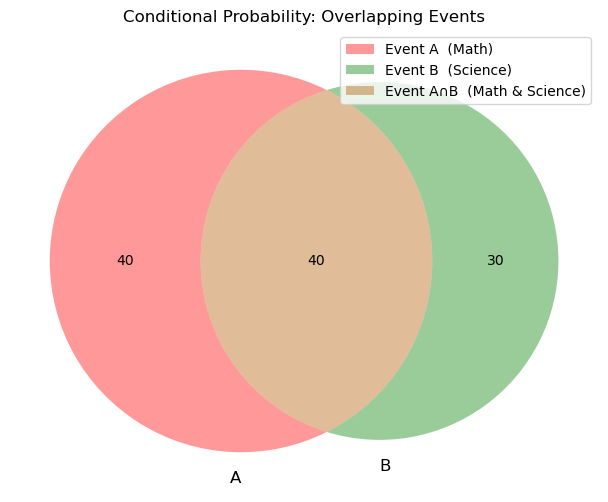

In [126]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles


# Total: 110 students
set_A_only   = 40   # passed Math only
set_B_only   = 30   # passed Science only
set_A_and_B  = 40   # passed both  → P(A∩B) = 40/110 ≈ 0.-27

plt.figure(figsize=(10, 6))  # width=10, height=6 (in inches)

# Drawing Venn diagram
venn_diagram_1 = venn2(subsets=(set_A_only, set_B_only, set_A_and_B))

# Drawing Venn diagram Outline
# venn_diagram_ = venn2_circles(subsets=(set_A_only, set_B_only, set_A_and_B), linewidth=1, color="white")

# Adding Labels and Title
plt.title("Conditional Probability: Overlapping Events")
plt.legend(labels=["Event A  (Math)", "Event B  (Science)", "Event A∩B  (Math & Science)"], loc="upper right")

plt.show()

## Example 02

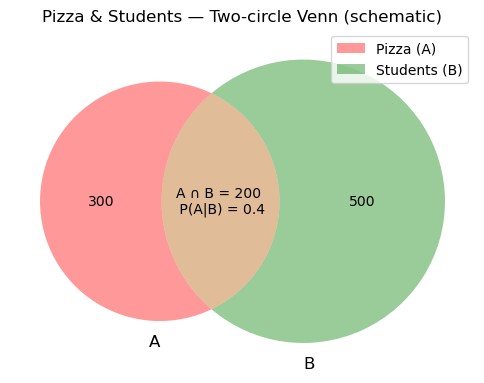

In [24]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 1000 people: 300 like pizza, 500 are students, 200 both

set_A_only   = 300   # like pizza only
set_B_only   = 500   # are students only
set_A_and_B  = 200   # are student and like pizza

# Therefore, the Conditional Probability is P(A|B) = P(A∩B) / P(B) = 200 / 500 = 0.4

plt.figure(figsize=(6, 6))

venn_diagram = venn2(subsets=(set_A_only, set_B_only, set_A_and_B), set_labels=("A", "B"))
venn_diagram.get_label_by_id("11").set_text("A ∩ B = 200 \n P(A|B) = 0.4")

plt.title("Pizza & Students — Two-circle Venn (schematic)")
plt.legend(labels=["Pizza (A)", "Students (B)"], loc="upper right")

plt.show()

## Example 03

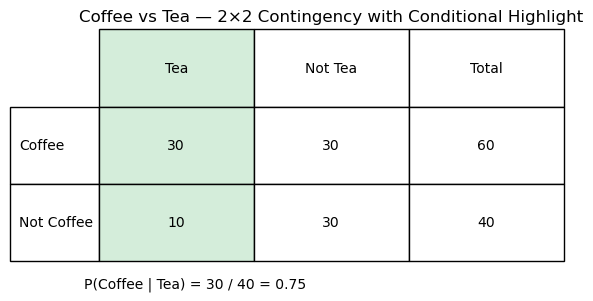

In [70]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array([[30, 30, 60],
                 [10, 30, 40]])

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=["Coffee", "Not Coffee"],
    colLabels=["Tea", "Not Tea", "Total"],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)

# শুধু Tea column highlight
for row in range(3):
    table[row, 0].set_facecolor("#d4edda")

plt.title("Coffee vs Tea — 2×2 Contingency with Conditional Highlight")
plt.figtext(0.1, 0.02, "P(Coffee | Tea) = 30 / 40 = 0.75")
plt.show()

# ☕ Conditional Probability — Visual Example

---

## 📊 Contingency Table — 100 জন Student

| | **Tea** | **Not Tea** | **Total** |
|---|---|---|---|
| **Coffee** | 30 | 30 | 60 |
| **Not Coffee** | 10 | 30 | 40 |

---

## 🧮 হিসাব

প্রশ্ন: **"Tea পছন্দ করে"** জানলে — **"Coffee পছন্দ করার"** সম্ভাবনা কত?

$$P(\text{Coffee} \mid \text{Tea}) = \frac{30}{40} = 0.75$$

---

## 💡 কেন 40 দিয়ে ভাগ করলাম?

Tea পছন্দ করে মোট **40 জন** — এরাই এখন আমাদের **নতুন sample space**।
এই 40 জনের মধ্যে **30 জন** coffee-ও পছন্দ করে।

> ✅ Conditional probability মানেই — পুরো 100 জন না দেখে শুধু **শর্তটি যাদের জন্য সত্য** তাদের মধ্যে focus করা।

---

# 🔀 Section 3: Independence

---

## 📌 Independence কী?

একটি event জানলে যদি অন্যটির সম্ভাবনা **একটুও না বদলায়** — তাহলে দুটো event **Independent**।

---

## 🔢 Formula

$$P(A \mid B) = P(A)$$

সমতুল্যভাবে:

$$P(A \cap B) = P(A) \times P(B)$$

---

## 🔵 Venn Diagram দিয়ে বোঝো

> দুটো বৃত্তের মধ্যে **কোনো overlap নেই** — A ও B সম্পূর্ণ **আলাদা**, একে অপরকে প্রভাবিত করে না।

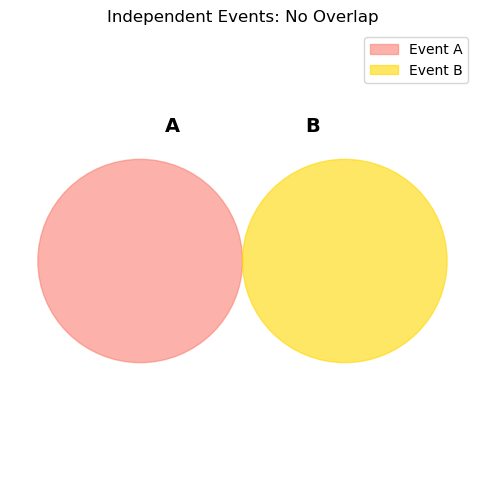

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 6))

# ax.add_patch(mpatches.Circle((0.35, 0.5), 0.22, color="salmon", alpha=0.6))
# ax.add_patch(mpatches.Circle((0.65, 0.5), 0.22, color="gold", alpha=0.6))

ax.add_patch(mpatches.Circle((0.28, 0.5), 0.22, color="salmon", alpha=0.6))
ax.add_patch(mpatches.Circle((0.72, 0.5), 0.22, color="gold",   alpha=0.6))

ax.text(0.35, 0.78, "A", fontsize=14, fontweight="bold", ha="center")
ax.text(0.65, 0.78, "B", fontsize=14, fontweight="bold", ha="center")

ax.legend(handles=[
    mpatches.Patch(color="salmon", alpha=0.6, label="Event A"),
    mpatches.Patch(color="gold",   alpha=0.6, label="Event B")
], loc="upper right")

plt.title("Independent Events: No Overlap")
plt.axis("off")
plt.show()

এই `venn` library টা দিয়ে independent (no overlap) diagram বানানো সম্ভব না। এটা সবসময় overlap দেখাবে।
**এই নির্দিষ্ট diagram টার জন্য manually `Circle` আঁকাই একমাত্র সঠিক উপায়।**
এই diagram এর concept ই হলো **no overlap** — তাই কোনো Venn library এর পক্ষে এটা সঠিকভাবে দেখানো সম্ভব না। 😊

## ⚖️ Independent vs Dependent — পার্থক্য

| | **Independent** | **Dependent** |
|---|---|---|
| **সম্পর্ক** | কোনো সম্পর্ক নেই | একটি অন্যটিকে প্রভাবিত করে |
| **Venn Diagram** | কোনো overlap নেই | overlap আছে |
| **Formula** | $P(A \cap B) = P(A) \times P(B)$ | $P(A \mid B) \neq P(A)$ |

> 💡 **ML-এ উদাহরণ:** Coin flip দুটি সবসময় **independent** — প্রথম flip-এর result দ্বিতীয়টিকে প্রভাবিত করে না।

---

# 🔗 Section 4: Conditional Independence

---

## 📌 Conditional Independence কী?

A এবং B **conditionally independent** given C — যদি:

$$P(A \mid B, C) = P(A \mid C)$$

> C জানা থাকলে B আর A সম্পর্কে **কোনো নতুন তথ্য** দেয় না।

---

## 🍦 উদাহরণ — Ice Cream Sales

- **A** = কেউ ice cream কিনবে
- **B** = আবহাওয়া sunny কিনা
- **C** = Temperature

**Temperature (C) জানা থাকলে** — "sunny কিনা (B)" জানলে আর বাড়তি কিছু জানা যায় না।

> ✅ তাই **A ও B conditionally independent given C**।

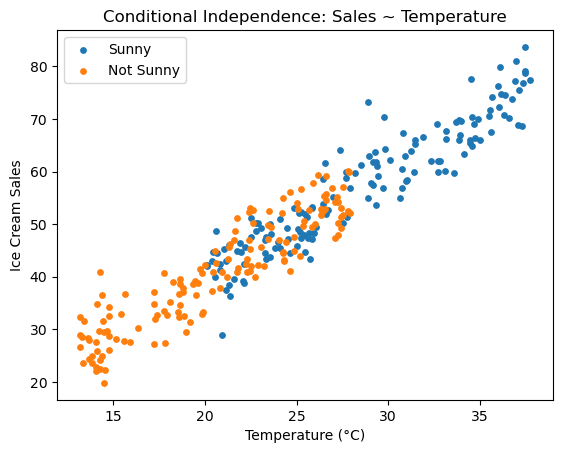

In [12]:
import matplotlib.pyplot as plt
import numpy as np


# Here we are setting the seed for reproducibility
np.random.seed(42)

# Sunny dataset
temp_sunny = np.random.uniform(20, 38, 150)
sales_sunny = temp_sunny * 2 + np.random.normal(0, 4, 150)

# Not Sunny dataset
temp_not_sunny = np.random.uniform(13, 28, 150)
sales_not_sunny = temp_not_sunny * 2 + np.random.normal(0, 4, 150)

plt.scatter(temp_sunny,     sales_sunny,     label="Sunny",     s=15)
plt.scatter(temp_not_sunny, sales_not_sunny, label="Not Sunny", s=15)

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales")
plt.title("Conditional Independence: Sales ~ Temperature")

plt.legend()
plt.show()

## 📊 Chart থেকে যা বোঝা যায়

Scatter plot-এ দেখা যাচ্ছে — **Sunny** ও **Not Sunny** উভয় ক্ষেত্রেই temperature বাড়লে ice cream sales বাড়ে। Sunny/Not Sunny-র আলাদা প্রভাব temperature জানা থাকলে **নগণ্য**।

---

## 🤖 ML-এ ব্যবহার

এই assumption ব্যবহার করে calculation সহজ করা হয়:

| Model | কীভাবে ব্যবহার করে |
|---|---|
| **Naive Bayes** | Class জানলে সব features independent ধরে |
| **Bayesian Networks** | Variables-এর মধ্যে conditional independence map করে |
| **Hidden Markov Models** | Current state জানলে past irrelevant ধরে |

যদি A ও B সবসময় independent হতো:
$$P(A, B) = P(A) \cdot P(B)$$

---

## 📚 আরেকটি উদাহরণ — Exam Pass

বাস্তব data-তে সাধারণত **dependencies** থাকে। তাই আমরা কোনো **"context" variable (C)**-এর উপর ভিত্তি করে independence assume করি।

| Variable | অর্থ |
|---|---|
| **A** | Student exam pass করবে কিনা |
| **B** | বন্ধুদের সাথে পড়েছে কিনা |
| **C** | মোট কত ঘণ্টা পড়েছে |

**Total study hours (C)** জানা থাকলে — বন্ধুদের সাথে পড়েছে কিনা **(B)** জানলে pass করার সম্ভাবনা **(A)**-তে তেমন কোনো পার্থক্য আসে না।

$$P(\text{Pass} \mid \text{StudiedWithFriends, Hours}) \approx P(\text{Pass} \mid \text{Hours})$$

> ✅ এটাই **Conditional Independence** — C জানা থাকলে B আর A-কে প্রভাবিত করে না।

---

# 🤖 Section 5: ML-এ Conditional Probability কেন গুরুত্বপূর্ণ?

---

## 📌 মূল কথা

**Conditional probability** model-কে **uncertainty**-র মধ্যেও prediction করতে সক্ষম করে।

---

## 🌍 Real-World উদাহরণ

| Application | Conditional Probability |
|---|---|
| **Spam detection** | $P(\text{Spam} \mid \text{"lottery" আছে})$ |
| **Medical diagnosis** | $P(\text{Disease} \mid \text{Test Positive})$ |
| **Recommender systems** | $P(\text{User likes item} \mid \text{Similar items পছন্দ করেছে})$ |

---

## ⚡ Independence Assumption যোগ করলে কী হয়?

**Conditional probability** + **Independence assumption** একসাথে দেয়:

- ✅ **Fast** — কম calculation
- ✅ **Interpretable** — বোঝা সহজ
- ✅ **Effective** — বাস্তবে ভালো কাজ করে

> 💡 এই combination-এর সেরা উদাহরণ → **Naive Bayes** — আজও **text classification**-এ ব্যাপকভাবে ব্যবহৃত হয়।

---

# 🚀 Section 6: Wrap-Up — Conditional Probability & Independence

---

## 🔑 মূল বিষয় তিনটি

| Concept | এক কথায় |
|---|---|
| **Conditional Probability** | একটি event আরেকটিকে **কীভাবে প্রভাবিত** করে |
| **Independence** | একটি event আরেকটিকে **কোনো প্রভাব ফেলে না** |
| **Conditional Independence** | কোনো context (C) জানলে বাকি সম্পর্ক **সরল হয়ে যায়** |

---

## 🤖 ML-এ এই ধারণাগুলোর ভূমিকা

এই তিনটি ধারণা মিলে অনেক ML algorithm-এর **ভিত্তি** তৈরি করে — যেগুলো **patterns** ও **uncertainty** থেকে শেখে।

> 💡 **মনে রাখো:** তোমার model যখন কোনো "smart guess" করে — আসলে সেটা সবসময় **probability-র খেলা**।

---

# 🧠 1. Bayes' Theorem & The Base-Rate Effect

---

## 📌 এই Lesson-এ যা শিখবো

**১. Bayes' Theorem আসলে কী**
— Math-এ না হারিয়ে মূল ধারণাটা বোঝা

**২. Base-Rate Effect**
— কীভাবে এটি আমাদের intuition **সম্পূর্ণ উল্টে** দিতে পারে

**৩. Real-World ML Problems-এ প্রয়োগ**
— যেমন **spam detection** ও **fraud detection**

> 💡 **মূল প্রশ্ন:** নতুন evidence পেলে আমাদের **belief কতটা বদলানো উচিত?** — এটাই Bayes' Theorem শেখায়।

---

# 📐 2. Bayes' Theorem — Concept Explanation

---

## 📌 মূল ধারণা

**Bayes' Theorem** হলো এমন একটি rule যা নতুন information আসলে আমাদের **belief আপডেট** করতে সাহায্য করে।

তিনটি ধাপ:
1. আগে যা বিশ্বাস করতাম → **Prior probability**
2. নতুন **evidence** দেখলাম
3. দুটো মিলিয়ে আপডেট করলাম → **Posterior probability**

---

## 🔢 Formula

$$P(A \mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

---

## 🔑 প্রতিটি অংশের অর্থ

| Symbol | নাম | অর্থ |
|---|---|---|
| $P(A)$ | **Prior** | Evidence দেখার **আগে** যা বিশ্বাস করতাম |
| $P(B \mid A)$ | **Likelihood** | Belief সত্যি হলে এই evidence দেখার সম্ভাবনা |
| $P(B)$ | **Evidence** | এই observation সাধারণত কতটা common |
| $P(A \mid B)$ | **Posterior** | Evidence দেখার **পরে** নতুন belief |

> 💡 **এক কথায়:** Prior + নতুন Evidence = **Posterior** — এটাই Bayes' Theorem-এর সার কথা।

---

## 💬 Bayes' Theorem — এক কথায়

> **"আমি দুনিয়া সম্পর্কে যা জানি, তার আলোকে এই নতুন clue-কে কতটা বিশ্বাস করা উচিত?"**

---

## 🤖 ML-এ এর প্রয়োগ

ML model নতুন data পেলে ঠিক এটাই করে —
**Prior knowledge** ও **নতুন evidence** — দুটো মিলিয়ে prediction **আপডেট** করে।

> ✅ এটাই Bayesian thinking-এর মূল — শুধু নতুন data নয়, **আগের জ্ঞানও** কাজে লাগাও।

---

# 🏥 Mini Example 1 — The Base-Rate Effect

---

## 🎯 পরিস্থিতি

- রোগটি হয় মাত্র **1000 জনে 1 জনের** (0.1%)
- Test **99% accurate**
- Test positive এলো — আসলেই রোগ আছে?

> 🧠 আমাদের **gut** বলে → **"99%!"** — কিন্তু এটা ভুল।

---

## 🔢 সঠিক হিসাব

1000 জনের মধ্যে:

| ফলাফল | সংখ্যা |
|---|---|
| আসলেই রোগ আছে + test positive ✅ | **1 জন** |
| রোগ নেই, কিন্তু test positive ❌ (false positive) | **~10 জন** |
| **মোট positive** | **11 জন** |

$$P(\text{Disease} \mid \text{Positive}) = \frac{1}{11} \approx 9\%$$

> 😲 Test **99% accurate** হওয়ার পরেও সত্যিকারের সম্ভাবনা মাত্র **~9%!**

---

## ⚠️ Base-Rate Effect কী?

কোনো কিছু কতটা **rare বা common** — সেটা ignore করলে probability **বিশাল overestimate** হয়ে যায়।

> 🔑 **মনে রাখো:** Accurate data থাকলেও **base rate** ignore করলে — মানুষ ও machine উভয়ই বোকা বনে যায়।

---

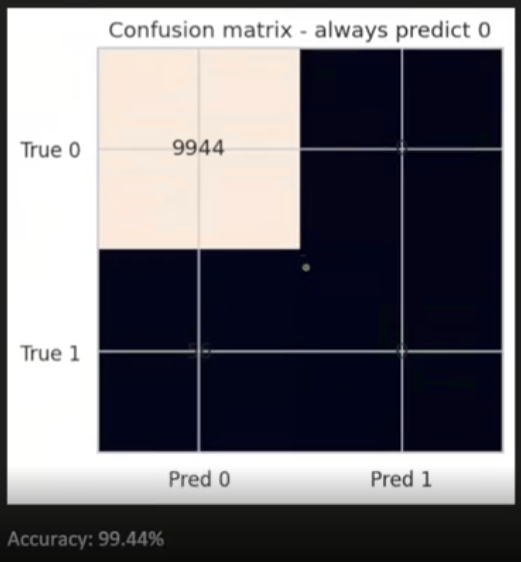

---

# 🚗 Real-Life Example: Police Car & Sports Car

---

## 🎯 পরিস্থিতি

রাতে একটি **red sports car** দ্রুত চলে গেল। বন্ধু বললো — *"এটা নিশ্চয়ই চোরাই গাড়ি!"*

এটি একটি **classic base-rate mistake।**

---

## 📊 Step 1: আমরা কী জানি?

| তথ্য | মান |
|---|---|
| শহরে চোরাই গাড়ির হার | **10,000-এ 1টি** (base rate — খুবই rare) |
| চোরাই গাড়ির মধ্যে sports car | **80%** |
| সাধারণ (non-stolen) গাড়ির মধ্যে sports car | **10%** |

**প্রশ্ন:** একটি sports car দেখলে সেটি চোরাই হওয়ার সম্ভাবনা কত?

---

## ❌ Step 2: Gut Reaction — ভুল চিন্তা

বন্ধু শুধু **clue**-টা দেখলো → *"এটা sports car।"*

যুক্তি দিলো:
> "বেশিরভাগ চোরাই গাড়ি sports car — তাই এটাও চোরাই হবে।"

এটি **logical মনে হলেও সম্পূর্ণ ভুল** — কারণ **base rate** সম্পূর্ণ ignore করা হয়েছে।

> ⚠️ **Base-rate mistake** তখনই হয় যখন আমরা শুধু **evidence** দেখি, কিন্তু ঘটনাটি আসলে কতটা **rare** সেটা ভুলে যাই।

---

## 🧮 Step 3: Bayes-style Reality Check

10,000টি গাড়ির মধ্যে:

| ধরন | সংখ্যা |
|---|---|
| চোরাই গাড়ি | **1টি** |
| চোরাই নয় | **9,999টি** |

Sports car হিসাব:
- Stolen sports cars = 80% of 1 = **0.8**
- Non-stolen sports cars = 10% of 9,999 = **~1,000**

$$P(\text{Stolen} \mid \text{Sports Car}) = \frac{0.8}{0.8 + 1000} \approx 0.08\%$$

> 😲 "বেশিরভাগ চোরাই গাড়ি sports car" — এটা সত্যি হলেও একটি random sports car চোরাই হওয়ার সম্ভাবনা মাত্র **1,000-এ 1-এরও কম!**

---

## 💡 The Point

বন্ধু **base rate** সম্পূর্ণ ignore করেছিল — চোরাই গাড়ি আসলে কতটা **rare** সেটা ভুলে গিয়েছিল।

> ⚠️ ঘটনাটি যখন **extremely uncommon**, তখন শক্তিশালী clue (যেমন "sports car") দিয়েও সম্ভাবনা বেশি হয় না।

---

## 🤖 ML-এ Base-Rate Effect

এই একই সমস্যা ঘটে:
- 🔍 **Fraud detection**
- 🏥 **Rare disease diagnosis**
- 🚨 **Anomaly detection**

Model যতই ভালো হোক — "suspicious" pattern spot করলেও **flagged cases-এর বেশিরভাগই false alarm** হয়।

**কারণ একটাই → real thing টা আসলে অনেক rare।**

> ⚠️ **Base-rate effect** মনে করিয়ে দেয় — underlying event যদি **rare** হয়, তাহলে strong evidence-ও তোমাকে **mislead** করতে পারে।

---

# 📧 4. Mini Real-World Use Case — Spam Detection

---

## 📌 Spam Classifier কীভাবে কাজ করে?

**Spam classifier** আসলে **Bayes' logic** ব্যবহার করে:

| অংশ | অর্থ |
|---|---|
| **Prior** | বেশিরভাগ email সাধারণ — এটাই model-এর আগের বিশ্বাস |
| **Evidence** | "prize" বা "urgent" শব্দ দেখলো |

---

## 🔢 Formula

$$P(\text{Spam} \mid \text{Word}) \propto P(\text{Word} \mid \text{Spam}) \times P(\text{Spam})$$

---

## 🧮 হিসাব

- "lottery" শব্দটি বেশিরভাগ spam-এ থাকে → $P(\text{Word} \mid \text{Spam})$ **বেশি**
- এটি **posterior probability** বাড়িয়ে দেয়

কিন্তু —
- Spam-এর **base rate** যদি মাত্র **5%** হয়
- তাহলে strong clue থাকলেও **100% certain** হওয়া যাবে না

---

## 🔍 Fraud Detection-এও একই কথা

Transaction সন্দেহজনক দেখালেই fraud নয় — কারণ **fraud আসলে rare**।

> 💡 **Bayes' Theorem** ML model-কে শেখায় — সবসময় **skeptical** থাকো, base rate কখনো ignore করো না।

---

# ✅ Summary & Reflection

---

## 🔑 মূল বিষয়গুলো

☑️ **Bayes' Theorem** — নতুন evidence আসলে আমাদের belief **আপডেট** করতে সাহায্য করে

☑️ **Base-rate effect** — **Prior** (overall frequency) সবসময় গুরুত্বপূর্ণ — এটি ignore করলে ভুল হয়

☑️ **ML-এ প্রয়োগ** — এই চিন্তাধারা চালায়:
- 📧 **Spam filters**
- 🏥 **Medical diagnosis models**
- 🔍 **Fraud detectors**

☑️ **সবসময় প্রশ্ন করো** — model-এর "confidence" কি আসলেই **evidence**-এর কারণে বেশি, নাকি শুধু **data imbalance**-এর কারণে?

---

# 🏥 Model Evaluation — Sensitivity, Specificity & Predictive Values

---

## 📌 সমস্যাটা কী?

ধরো একটি ML model predict করে — কেউ **diabetes**-এ আক্রান্ত কিনা।
Result দেয়: **Positive** (আছে) বা **Negative** (নেই)।

---

## ⚠️ Accuracy একা যথেষ্ট নয়

Model **95% accurate** হলেও — data **imbalanced** হলে model **সম্পূর্ণ ব্যর্থ** হতে পারে।

> 💡 **উদাহরণ:** 95% মানুষ সুস্থ হলে model সবাইকে "Negative" বললেও 95% accurate হবে — কিন্তু কোনো রোগী ধরতে পারবে না!

---

## 🔍 তাহলে সত্যিকারের ভালো model চেনার উপায়?

এই metrics গুলো দিয়ে:

| Metric | কী পরিমাপ করে |
|---|---|
| **Sensitivity** | আসল positive কতটা ধরা পড়ছে |
| **Specificity** | আসল negative কতটা সঠিকভাবে চিহ্নিত হচ্ছে |
| **False Positive Rate** | সুস্থকে ভুলভাবে রোগী বলার হার |
| **False Negative Rate** | রোগীকে ভুলভাবে সুস্থ বলার হার |
| **PPV** (Positive Predictive Value) | Positive বললে কতবার সত্যিই positive |
| **NPV** (Negative Predictive Value) | Negative বললে কতবার সত্যিই negative |

---

# 📊 Confusion Matrix — সংক্ষিপ্ত নোট

---

## 📌 Confusion Matrix কী?

Model কোথায় সঠিক, কোথায় ভুল — তার **report card**।

| | **Predicted Positive** | **Predicted Negative** |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

---

## 🧮 উদাহরণ — 100 জন Diabetes Test

| ফলাফল | সংখ্যা |
|---|---|
| আসলেই diabetes আছে এবং model ধরেছে → **TP** | 9 |
| আসলেই diabetes আছে কিন্তু model miss করেছে → **FN** | 1 |
| সুস্থ কিন্তু model ভুলভাবে diabetic বলেছে → **FP** | 5 |
| সুস্থ এবং model সঠিকভাবে সুস্থ বলেছে → **TN** | 85 |

---

## 🔑 চার ধরনের ফলাফল মনে রাখার উপায়

- **True** → model **সঠিক** সিদ্ধান্ত নিয়েছে
- **False** → model **ভুল** সিদ্ধান্ত নিয়েছে
- **Positive** → model বলেছে "আছে"
- **Negative** → model বলেছে "নেই"

> ✅ এই চারটি মান থেকেই **Sensitivity, Specificity, PPV, NPV** — সব কিছু calculate করা যায়।

---

# 🎯 Sensitivity / Recall

---

## 📌 Sensitivity কী?

সব **আসল positive** case-এর মধ্যে model কতটা **ধরতে পেরেছে**।

$$\text{Sensitivity} = \frac{TP}{TP + FN}$$

---

## 🧮 উদাহরণ

$$\text{Sensitivity} = \frac{9}{9 + 1} = 0.9 = \textbf{90\%}$$

---

## 💡 Sensitivity বেশি মানে কী?

> Real positive **খুব কমই miss** হয়।

**Smoke detector** analogy:
- **High sensitivity** detector → সামান্য ধোঁয়াতেও বেজে ওঠে
- বারবার বাজতে পারে — কিন্তু **আগুন কখনো miss করবে না** ✅

---

## 🏥 Healthcare-এ কেন জরুরি?

আসলে অসুস্থ কাউকে **"সুস্থ"** বলে miss করা যাবে না — তাই **Sensitivity সবচেয়ে গুরুত্বপূর্ণ**।

> ⚠️ **FN (False Negative)** বেশি হলে Sensitivity কমে — এটি healthcare-এ **সবচেয়ে বিপজ্জনক ভুল**।

---

# 🛡️ Specificity

---

## 📌 Specificity কী?

সব **আসল negative** case-এর মধ্যে model কতটা **সঠিকভাবে negative বলতে পেরেছে**।

$$\text{Specificity} = \frac{TN}{TN + FP}$$

---

## 🧮 উদাহরণ

$$\text{Specificity} = \frac{85}{85 + 5} = 0.944 = \textbf{94.4\%}$$

→ Model **94%** সুস্থ মানুষকে সঠিকভাবে "সুস্থ" বলতে পেরেছে।

---

## 💡 Security Guard Analogy

**Specificity** = Security guard যে ঠিক করে **কাকে ঢুকতে দেবে না**।

- **High specificity** guard → নির্দোষ মানুষকে **ভুলভাবে আটকায় না** ✅
- **Low specificity** → অনেক সুস্থ মানুষকে ভুলভাবে "রোগী" বলে → **FP বেড়ে যায়**

> ⚠️ **Sensitivity vs Specificity trade-off:**
> Sensitivity বাড়ালে সাধারণত Specificity কমে — দুটোর মধ্যে **balance** খুঁজে বের করাই আসল চ্যালেঞ্জ।

---

# ❌ False Positive & False Negative Rates

---

## 📌 Formula

**False Positive Rate (FPR):**
$$FPR = \frac{FP}{FP + TN}$$
→ সুস্থ মানুষকে ভুলভাবে **"রোগী"** বলার হার

**False Negative Rate (FNR):**
$$FNR = \frac{FN}{FN + TP}$$
→ আসল রোগীকে ভুলভাবে **"সুস্থ"** বলার হার

---

## 🔗 Sensitivity ও Specificity-এর সাথে সম্পর্ক

| | সম্পর্ক |
|---|---|
| **FPR** | = 1 − Specificity |
| **FNR** | = 1 − Sensitivity |

---

## ⚖️ Trade-off

দুটোই **যতটা সম্ভব কম** রাখা উচিত — কিন্তু সবসময় **trade-off** থাকে:

> Sensitivity বাড়ালে (বেশি positive ধরলে) → **FPR বেড়ে যায়**

| ক্ষেত্র | কোনটা বেশি ক্ষতিকর |
|---|---|
| 🏥 Cancer detection | **FNR** — রোগী miss করা বিপজ্জনক |
| 📧 Spam filter | **FPR** — important email spam-এ যাওয়া সমস্যা |

---

# 🎯 PPV & NPV — Model-এর Prediction কতটা বিশ্বাসযোগ্য?

---

## 📌 PPV (Positive Predictive Value) = Precision

$$PPV = \frac{TP}{TP + FP}$$

> Model "positive" বললে কতবার **সত্যিই positive**?

$$PPV = \frac{9}{9 + 5} = 0.64 = \textbf{64\%}$$

---

## 📌 NPV (Negative Predictive Value)

$$NPV = \frac{TN}{TN + FN}$$

> Model "negative" বললে কতবার **সত্যিই negative**?

$$NPV = \frac{85}{85 + 1} = 0.988 = \textbf{98.8\%}$$

---

## 🔍 ফলাফল বিশ্লেষণ

| Metric | মান | অর্থ |
|---|---|---|
| **PPV** | 64% | Positive prediction মাত্র 64% সঠিক |
| **NPV** | 98.8% | Negative prediction প্রায় সবসময় সঠিক |

> ⚠️ Model **"সুস্থ"** বলতে ভালো — কিন্তু **"রোগী"** ধরতে দুর্বল। এটাই **imbalanced dataset**-এর সাধারণ সমস্যা।

---

# 💼 Mini Real-World Use Case — Job Application Screening AI

---

## 🎯 Scenario

একটি company ML model দিয়ে job applicants **filter** করছে:
- **Positive** = Suitable candidate
- **Negative** = Not suitable

---

## 🔍 Confusion Matrix এই context-এ

| ফলাফল | বাস্তব অর্থ |
|---|---|
| **True Positive (TP)** | সত্যিকারের দক্ষ candidate shortlist হয়েছে ✅ |
| **False Positive (FP)** | অযোগ্য candidate select হয়েছে → interviewer-এর সময় নষ্ট ❌ |
| **False Negative (FN)** | ভালো candidate reject হয়েছে → বড় ক্ষতি ❌ |
| **True Negative (TN)** | অযোগ্য candidate সঠিকভাবে বাদ পড়েছে ✅ |

---

## ⚖️ Insight — কোন লক্ষ্যে কোনটা দরকার?

| লক্ষ্য | কী বাড়াতে হবে |
|---|---|
| কোনো ভালো candidate **miss করা যাবে না** | **High Sensitivity** |
| দুর্বল applicant-এ interview slot **নষ্ট করা যাবে না** | **High Specificity** |

> 💡 **মনে রাখো:** একই model-এ Sensitivity ও Specificity দুটো একসাথে সর্বোচ্চ করা যায় না — **business goal** অনুযায়ী **trade-off** ঠিক করতে হয়।

---

## 🚗 II. Autonomous Car — Pedestrian Detection

**Scenario:** ML model detect করছে রাস্তায় **pedestrian আছে কিনা**:
- **Positive** = Pedestrian detected
- **Negative** = No pedestrian

---

## ⚠️ ভুলের পরিণাম

| ভুল | কী হয় |
|---|---|
| **False Negative** (pedestrian miss) | **Accident** হতে পারে 🚨 |
| **False Positive** (ghost pedestrian) | অকারণে brake → traffic slow হয় |

---

## 💡 Insight

> **False Negative** এখানে **অনেক বেশি বিপজ্জনক** — তাই **High Sensitivity** অপরিহার্য।

কিছু **false alarm** সহ্য করা যায় — কিন্তু একজন **real pedestrian miss** করা একেবারেই চলবে না।

---

## 📱 III. Face Unlock on Smartphones

**Scenario:** Phone **facial recognition** দিয়ে unlock হচ্ছে:
- **Positive** = Authorized face detected
- **Negative** = Unauthorized face

---

## ⚠️ ভুলের পরিণাম

| ভুল | কী হয় |
|---|---|
| **False Positive** (অন্যের মুখে unlock) | **Security breach** 🚨 |
| **False Negative** (নিজের মুখ চিনছে না) | বিরক্তিকর — কিন্তু **safe** ✅ |

---

## 💡 Insight

> Face unlock system **High Specificity** favor করে — অপরিচিত কেউ যেন ঢুকতে না পারে।

কম আলোয় মাঝেমাঝে নিজের মুখ **reject** হলেও চলবে — কিন্তু **অন্য কেউ access পাবে না**।

---

## 🔑 তিনটি Use Case-এর তুলনা

| Scenario | বেশি গুরুত্বপূর্ণ |
|---|---|
| **Job screening** | Goal অনুযায়ী trade-off |
| **Autonomous car** | **High Sensitivity** |
| **Face unlock** | **High Specificity** |

---

## 📋 Summary — এক নজরে

| Metric | কী পরিমাপ করে |
|---|---|
| **Sensitivity** | Model কতটা ভালো **positive ধরতে** পারে |
| **Specificity** | Model কতটা ভালো **false alarm এড়াতে** পারে |
| **FPR / FNR** | Model কী ধরনের **ভুল** করছে |
| **PPV / NPV** | Model-এর prediction কতটা **বিশ্বাসযোগ্য** |

---

# ⚖️ Class Imbalance & Its Impact on Interpreting Errors

---

## 🎯 এই Chapter-এ যা শিখবো

- ✅ **Class imbalance** কী
- ✅ কেন **Accuracy misleading** হতে পারে
- ✅ Model সঠিকভাবে **evaluate** করার উপায়

---

# 📊 Class Imbalance — Concept Explanation

---

## 📌 Class Imbalance কী?

একটি class-এ অন্যটির চেয়ে **অনেক বেশি sample** থাকা।

**Real-life উদাহরণ:**

| Dataset | Imbalance |
|---|---|
| **Spam detection** | বেশিরভাগ email **spam নয়** |
| **Disease prediction** | বেশিরভাগ মানুষ **সুস্থ** |
| **Credit card fraud** | বেশিরভাগ transaction **safe** |

---

## 😴 Model "Lazy" হয়ে যায়!

Dataset **90% একটি class** হলে — model শিখে নেয় সবসময় **majority class** predict করতে।
তবুও **90% accurate** দেখায় — কিন্তু আসলে **কিছুই শেখেনি**।

---

## ⚠️ Accuracy কেন Misleading?

**True Negatives** score-কে **dominate** করে — তাই Accuracy বেশি দেখায়।

---

## 🔧 সমাধান — Better Metrics ব্যবহার করো

| Metric | কী পরিমাপ করে |
|---|---|
| **Precision** | Predicted positive-এর মধ্যে কতটা সত্যিই সঠিক |
| **Recall (Sensitivity)** | আসল positive-এর মধ্যে কতটা ধরা পড়েছে |

---

# Visual and Mathematical Explanation

---

## 🔢 Imbalance কীভাবে Confusion Matrix-কে ফাঁকি দেয়?

Dataset-এ **990টি "No Fraud"** এবং মাত্র **10টি "Fraud"** থাকলে:

| | **Predicted Positive** | **Predicted Negative** |
|---|---|---|
| **Actual Positive** | TP (সঠিক detection) | FN (miss হয়েছে) |
| **Actual Negative** | FP (false alarm) | **TN (অনেক বেশি)** |

Matrix-এর বেশিরভাগ cell **TN (True Negative)**-এ ভরে যায়।

> ⚠️ Model **প্রতিটি fraud miss** করলেও Accuracy **উচ্চ** দেখায়!

---

## 🎯 তাই Focus বদলাতে হবে

**Overall accuracy** → **Error types**-এ মনোযোগ দাও।

---

## 🚨 Imbalanced Problem-এ False Negative বেশি ক্ষতিকর

> 🏥 Cancer test-এ অসুস্থ রোগীকে **"সুস্থ"** বলা → **Critical miss** — এটি সবচেয়ে বিপজ্জনক ভুল।

---

## 🏥 Mini Real-World Use Case — Medical Diagnosis

**Scenario:** Rare disease detect করার model তৈরি করছো।
- মাত্র **2% patient** আসলে অসুস্থ

Model যদি সবাইকে **"healthy"** বলে দেয় →
- **Accuracy = 98%** ✅ (দেখতে ভালো)
- কিন্তু **সব আসল রোগী miss** ❌ (সম্পূর্ণ ব্যর্থ)

> 🔑 **Healthcare-এ Recall (Sensitivity) সবচেয়ে গুরুত্বপূর্ণ** — যতটা সম্ভব বেশি **actual positive** ধরতে হবে।

---

## 📧 Example 2 — Spam Detection

Spam filter-এ real email ভুলভাবে spam হলে (**False Positive**) →
- বিরক্তিকর — কিন্তু **বিপজ্জনক নয়**

তাই এখানে **Precision** বেশি গুরুত্বপূর্ণ — বেশি legit email **block করা যাবে না**।

---

## 🔑 মূল শিক্ষা

> **আলাদা problem-এ model error-এর interpretation আলাদা হয়।**

| Scenario | বেশি গুরুত্বপূর্ণ | কারণ |
|---|---|---|
| 🏥 Medical diagnosis | **Recall** | রোগী miss করা বিপজ্জনক |
| 📧 Spam detection | **Precision** | legit email block করা সমস্যা |

---

## ✅ Summary & Reflection

| মূল শিক্ষা | বিস্তারিত |
|---|---|
| **Class imbalance** | একটি class dataset-কে **dominate** করে |
| **Accuracy মিথ্যা বলতে পারে** | সবসময় **Precision, Recall ও F1-score** দেখো |
| **Context matters** | Healthcare → **Recall**, Spam detection → **Precision** |
| **Imbalance handle করার উপায়** | **Resampling, Class weights, Threshold tuning** — পরে বিস্তারিত আসবে |

---

---